# Supervised, Semi-Supervised, and Unsupervised Learning

Import packages

In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, GridSearchCV, train_test_split
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay 
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans, SpectralClustering
from scipy.special import softmax

### (a) Download the Breast Cancer Wisconsin (Diagnostic) Data Set

In [3]:
wdbc_columns = ['ID', 'Diagnosis', 'radius1', 'texture1', 'perimeter1', 'area1', 'smoothness1', 'compactness1', 'concavity1', 'concave_points1', 
                'symmetry1', 'fractal_dimension1', 'radius2', 'texture2', 'perimeter2', 'area2', 'smoothness2', 'compactness2', 'concavity2', 
                'concave_points2', 'symmetry2', 'fractal_dimension2', 'radius3', 'texture3', 'perimeter3', 'area3', 'smoothness3', 'compactness3', 
                'concavity3', 'concave_points3', 'symmetry3', 'fractal_dimension3']
wdbc_df = pd.read_csv('../data/wdbc.data', names= wdbc_columns)
wdbc_df

,ID,Diagnosis,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


### (b) Monte-Carlo Simulation

#### (i) Supervised Learning

Average Train Accuracy of Monte Carlo Simulation with SVM w/ L1-Regularization: 0.993919413919414
Average Train AUROC of Monte Carlo Simulation with SVM w/ L1-Regularization: 0.9988480098611004
Average Train Precision of Monte Carlo Simulation with SVM w/ L1-Regularization: 0.9952123408896943
Average Train Recall of Monte Carlo Simulation with SVM w/ L1-Regularization: 0.9883549766735069
Average Train F1-Score of Monte Carlo Simulation with SVM w/ L1-Regularization: 0.9917629714132803

Average Test Accuracy of Monte Carlo Simulation with SVM w/ L1-Regularization: 0.9596491228070173
Average Test AUROC of Monte Carlo Simulation with SVM w/ L1-Regularization: 0.9902615020925161
Average Test Precision of Monte Carlo Simulation with SVM w/ L1-Regularization: 0.948750197822919
Average Test Recall of Monte Carlo Simulation with SVM w/ L1-Regularization: 0.946562525823136
Average Test F1-Score of Monte Carlo Simulation with SVM w/ L1-Regularization: 0.9467870458907027


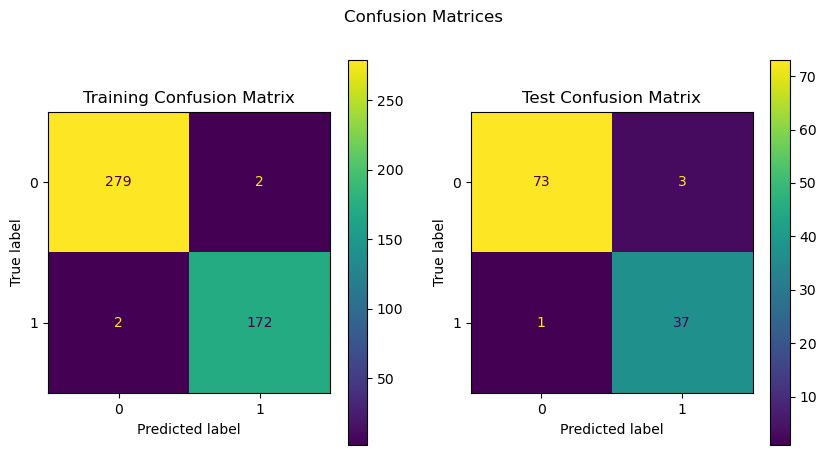

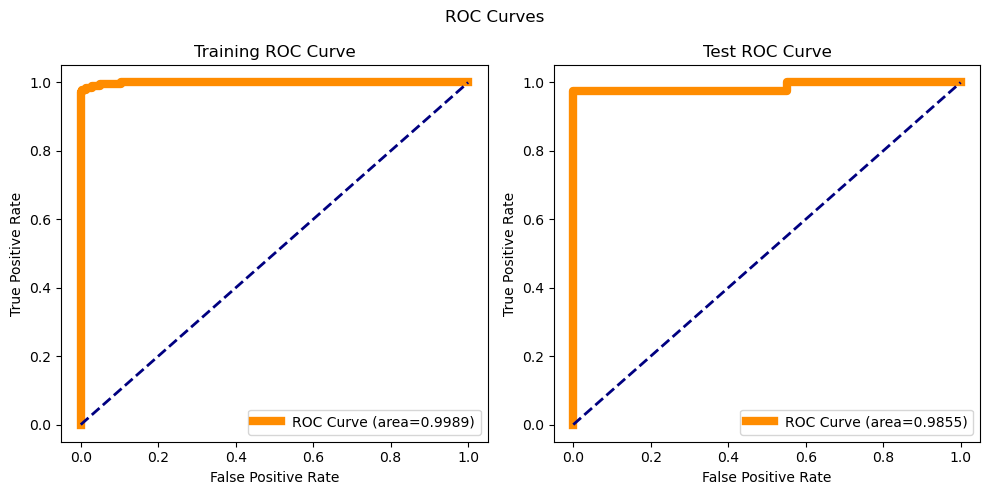

In [4]:
X = wdbc_df.iloc[:, 2:]
y = wdbc_df['Diagnosis']

train_accuracies = []
train_auroc_scores = []
train_f1_scores = []
train_precision_scores = []
train_recall_scores = []

test_accuracies = []
test_auroc_scores = []
test_f1_scores = []
test_precision_scores = []
test_recall_scores = []

for M in range(0,30):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
    C_list = [0.001, 0.01, 0.1, 1, 10]
    kfold = KFold(n_splits=5, shuffle=True)
    results = {'C':[], '# of Times Picked': [], 'Mean Accuracy':[]}
    accuracy_dict = {C: [] for C in C_list}
    num_picks_dict = {C: 0 for C in C_list}
    
    for train_index, val_index in kfold.split(X_train, y_train):
        X_subtrain, X_val = X_train.iloc[train_index], X_train.iloc[val_index]
        y_subtrain, y_val = y_train.iloc[train_index], y_train.iloc[val_index]
        
        scaler = StandardScaler()
        X_subtrain_scaled = scaler.fit_transform(X_subtrain)
        X_val_scaled = scaler.transform(X_val)

        param_grid = {'C': C_list}
        l1_svm = LinearSVC(penalty='l1', dual=False, max_iter=200000)
        grid_search = GridSearchCV(estimator=l1_svm, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)
        grid_search.fit(X_subtrain, y_subtrain)
        best_C = grid_search.best_params_['C']

        best_l1_svm = LinearSVC(penalty='l1', dual=False, C=best_C, max_iter=200000) 
        best_l1_svm.fit(X_subtrain, y_subtrain)
        y_pred = best_l1_svm.predict(X_val)
        accuracy = accuracy_score(y_val, y_pred)

        accuracy_dict[best_C].append(accuracy)
        num_picks_dict[best_C] += 1

        for C_value, accuracies in accuracy_dict.items():
            if accuracies:            
                mean_accuracy = sum(accuracies) / len(accuracies)
                results['C'].append(C_value)
                results['Mean Accuracy'].append(mean_accuracy)
                num_picks = num_picks_dict[C_value]
                results['# of Times Picked'].append(num_picks)
        
    results_df = pd.DataFrame(results).sort_values(by=['# of Times Picked', 'Mean Accuracy'], ascending=[False, False])
    optimal_C = results_df.iloc[0]['C']
    optimal_l1_svm = LinearSVC(penalty='l1', C=optimal_C, dual=False, max_iter=200000)
    log_reg = LogisticRegression(penalty='l1', solver='saga', C=optimal_C, max_iter=200000)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    optimal_l1_svm.fit(X_train_scaled, y_train)
    log_reg.fit(X_train_scaled, y_train)
    y_train_pred = optimal_l1_svm.predict(X_train_scaled)
    y_test_pred = optimal_l1_svm.predict(X_test_scaled)
    y_train_pred_prob = log_reg.predict_proba(X_train_scaled)[:, 1]
    y_test_pred_prob = log_reg.predict_proba(X_test_scaled)[:, 1]

    train_auroc = roc_auc_score(y_train, y_train_pred_prob)
    train_accuracy = accuracy_score(y_train, y_train_pred)
    train_precision = precision_score(y_train, y_train_pred, pos_label='M')
    train_recall = recall_score(y_train, y_train_pred, pos_label='M')
    train_f1 = f1_score(y_train, y_train_pred, pos_label='M')

    test_auroc = roc_auc_score(y_test, y_test_pred_prob)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    test_precision = precision_score(y_test, y_test_pred, pos_label='M')
    test_recall = recall_score(y_test, y_test_pred, pos_label='M')
    test_f1 = f1_score(y_test, y_test_pred, pos_label='M')

    train_auroc_scores.append(train_auroc)
    train_accuracies.append(train_accuracy)
    train_precision_scores.append(train_precision)
    train_recall_scores.append(train_recall)
    train_f1_scores.append(train_f1)
    
    test_auroc_scores.append(test_auroc)
    test_accuracies.append(test_accuracy)
    test_precision_scores.append(test_precision)
    test_recall_scores.append(test_recall)
    test_f1_scores.append(test_f1)

avg_train_accuracy = np.mean(train_accuracies)
avg_train_auroc = np.mean(train_auroc_scores)
avg_train_precision = np.mean(train_precision_scores)
avg_train_recall = np.mean(train_recall_scores)
avg_train_f1 = np.mean(train_f1_scores)

avg_test_accuracy_supervised = np.mean(test_accuracies)
avg_test_auroc_supervised = np.mean(test_auroc_scores)
avg_test_precision_supervised = np.mean(test_precision_scores)
avg_test_recall_supervised = np.mean(test_recall_scores)
avg_test_f1_supervised = np.mean(test_f1_scores)

print('Average Train Accuracy of Monte Carlo Simulation with SVM w/ L1-Regularization:', avg_train_accuracy)
print('Average Train AUROC of Monte Carlo Simulation with SVM w/ L1-Regularization:', avg_train_auroc)
print('Average Train Precision of Monte Carlo Simulation with SVM w/ L1-Regularization:', avg_train_precision)
print('Average Train Recall of Monte Carlo Simulation with SVM w/ L1-Regularization:', avg_train_recall)
print('Average Train F1-Score of Monte Carlo Simulation with SVM w/ L1-Regularization:', avg_train_f1)
print('')

print('Average Test Accuracy of Monte Carlo Simulation with SVM w/ L1-Regularization:', avg_test_accuracy_supervised)
print('Average Test AUROC of Monte Carlo Simulation with SVM w/ L1-Regularization:', avg_test_auroc_supervised)
print('Average Test Precision of Monte Carlo Simulation with SVM w/ L1-Regularization:', avg_test_precision_supervised)
print('Average Test Recall of Monte Carlo Simulation with SVM w/ L1-Regularization:', avg_test_recall_supervised)
print('Average Test F1-Score of Monte Carlo Simulation with SVM w/ L1-Regularization:', avg_test_f1_supervised)

train_conf_matrix = confusion_matrix(y_train, y_train_pred)
test_conf_matrix = confusion_matrix(y_test, y_test_pred)

fig, axis = plt.subplots(1, 2, figsize=(10, 5))
train_disp = ConfusionMatrixDisplay(confusion_matrix=train_conf_matrix)
test_disp = ConfusionMatrixDisplay(confusion_matrix=test_conf_matrix)
train_disp.plot(ax=axis[0])
test_disp.plot(ax=axis[1])
axis[0].set_title("Training Confusion Matrix")
axis[1].set_title("Test Confusion Matrix")
plt.suptitle("Confusion Matrices")

fig, axis = plt.subplots(1, 2, figsize=(10, 5))
train_fpr, train_tpr, train_thresholds = roc_curve(y_train, y_train_pred_prob, pos_label='M')
test_fpr, test_tpr, test_thresholds = roc_curve(y_test, y_test_pred_prob, pos_label='M')
axis[0].plot(train_fpr, train_tpr, color='darkorange', lw=6, label=f'ROC Curve (area={train_auroc:.4f})')
axis[0].plot([0,1], [0,1], color='navy', lw=2, linestyle='--')
axis[0].set_xlabel('False Positive Rate')
axis[0].set_ylabel('True Positive Rate')
axis[0].set_title('Training ROC Curve')
axis[0].legend(loc='lower right')
axis[1].plot(test_fpr, test_tpr, color='darkorange', lw=6, label=f'ROC Curve (area={test_auroc:.4f})')
axis[1].plot([0,1], [0,1], color='navy', lw=2, linestyle='--')
axis[1].set_xlabel('False Positive Rate')
axis[1].set_ylabel('True Positive Rate')
axis[1].set_title('Test ROC Curve')
axis[1].legend(loc='lower right')
plt.suptitle("ROC Curves")

plt.tight_layout()
plt.show()

#### (ii) Semi-Supervised Learning/ Self-training

##### (A)

In [5]:
optimal_C_list = []
labeled_index_list = []
unlabeled_index_list = []

for M in range(0,30): 
    train_df, test_df = train_test_split(wdbc_df, test_size=0.2)
    positive_df = train_df[train_df['Diagnosis'] == 'M']
    negative_df = train_df[train_df['Diagnosis'] == 'B']
    
    positive_labeled = positive_df.sample(frac=0.5)
    positive_unlabeled_indices = positive_df.index.difference(positive_labeled.index)
    positive_unlabeled = positive_df.loc[positive_unlabeled_indices]
    negative_labeled = negative_df.sample(frac=0.5)
    negative_unlabeled_indices = negative_df.index.difference(negative_labeled.index)
    negative_unlabeled = negative_df.loc[negative_unlabeled_indices]
    
    labeled_df = pd.concat((positive_labeled, negative_labeled), axis=0)
    labeled_index = labeled_df.index
    labeled_index_list.append(labeled_index)
    X_labeled = labeled_df.iloc[:, 2:]
    y_labeled = labeled_df['Diagnosis']
    
    unlabeled_df = pd.concat((positive_unlabeled, negative_unlabeled), axis=0)
    unlabeled_index = unlabeled_df.index
    unlabeled_index_list.append(unlabeled_index)
    
    X_labeled_train, X_labeled_test, y_labeled_train, y_labeled_test = train_test_split(X_labeled, y_labeled, test_size=0.2)
    C_list = [0.001, 0.01, 0.1, 1, 10]
    kfold = KFold(n_splits=5, shuffle=True)
    results = {'C':[], '# of Times Picked': [], 'Mean Accuracy':[]}
    accuracy_dict = {C: [] for C in C_list}
    num_picks_dict = {C: 0 for C in C_list}
    
    for train_index, val_index in kfold.split(X_labeled_train, y_labeled_train):
        X_subtrain, X_val = X_labeled_train.iloc[train_index], X_labeled_train.iloc[val_index]
        y_subtrain, y_val = y_labeled_train.iloc[train_index], y_labeled_train.iloc[val_index]
        
        scaler = StandardScaler()
        X_subtrain_scaled = scaler.fit_transform(X_subtrain)
        X_val_scaled = scaler.transform(X_val)
    
        param_grid = {'C': C_list}
        l1_svm = LinearSVC(penalty='l1', dual=False, max_iter=400000)
        grid_search = GridSearchCV(estimator=l1_svm, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)
        grid_search.fit(X_subtrain, y_subtrain)
        best_C = grid_search.best_params_['C']
    
        best_l1_svm = LinearSVC(penalty='l1', dual=False, C=best_C, max_iter=400000) 
        best_l1_svm.fit(X_subtrain, y_subtrain)
        y_pred = best_l1_svm.predict(X_val)
        accuracy = accuracy_score(y_val, y_pred)
    
        accuracy_dict[best_C].append(accuracy)
        num_picks_dict[best_C] += 1
    
        for C_value, accuracies in accuracy_dict.items():
            if accuracies:            
                mean_accuracy = sum(accuracies) / len(accuracies)
                results['C'].append(C_value)
                results['Mean Accuracy'].append(mean_accuracy)
                num_picks = num_picks_dict[C_value]
                results['# of Times Picked'].append(num_picks)
        
    results_df = pd.DataFrame(results).sort_values(by=['# of Times Picked', 'Mean Accuracy'], ascending=[False, False])
    optimal_C = results_df.iloc[0]['C']
    optimal_C_list.append(optimal_C)

##### (B)

Average Train Accuracy of Monte Carlo Simulation with Self-Trained SVM w/ L1-Regularization: 0.9883516483516483
Average Train AUROC of Monte Carlo Simulation with Self-Trained SVM w/ L1-Regularization: 0.9747189457964288
Average Train Precision of Monte Carlo Simulation with Self-Trained SVM w/ L1-Regularization: 0.9893000296608517
Average Train Recall of Monte Carlo Simulation with Self-Trained SVM w/ L1-Regularization: 0.9785506322718154
Average Train F1-Score of Monte Carlo Simulation with Self-Trained SVM w/ L1-Regularization: 0.9837951929047343

Average Test Accuracy of Monte Carlo Simulation with Self-Trained SVM w/ L1-Regularization: 0.9543859649122804
Average Test AUROC of Monte Carlo Simulation with Self-Trained SVM w/ L1-Regularization: 0.9679050925893896
Average Test Precision of Monte Carlo Simulation with Self-Trained SVM w/ L1-Regularization: 0.9402569169427978
Average Test Recall of Monte Carlo Simulation with Self-Trained SVM w/ L1-Regularization: 0.9350044562025313
Ave

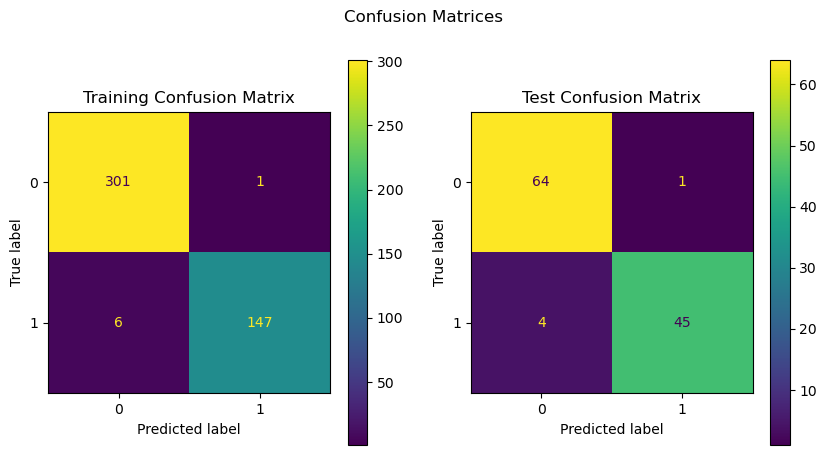

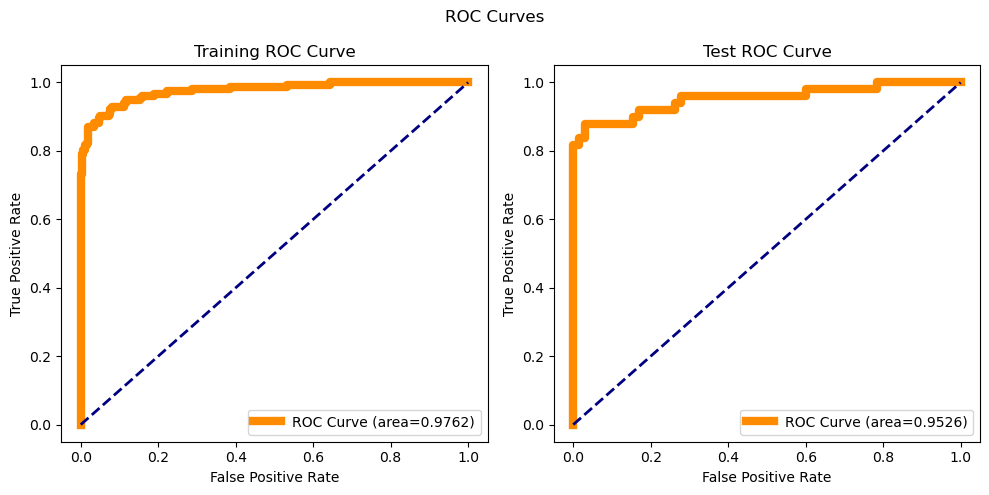

In [6]:
train_accuracies = []
train_auroc_scores = []
train_f1_scores = []
train_precision_scores = []
train_recall_scores = []

test_accuracies = []
test_auroc_scores = []
test_f1_scores = []
test_precision_scores = []
test_recall_scores = []

for M in range(0,30):
    train_labeled = wdbc_df.loc[np.array(labeled_index_list[M])]
    train_unlabeled = wdbc_df.loc[np.array(unlabeled_index_list[M])]
    test_set_indices = wdbc_df.index.difference(np.concatenate((labeled_index_list[M], unlabeled_index_list[M]), axis=0))
    test_set = wdbc_df.loc[test_set_indices]
    
    X_train_labeled = train_labeled.iloc[:, 2:]
    y_train_labeled = train_labeled['Diagnosis']
    X_train_unlabeled = train_unlabeled.iloc[:, 2:]
    y_train_unlabeled = train_unlabeled['Diagnosis']
    X_test = test_set.iloc[:, 2:]
    y_test = test_set['Diagnosis']
    
    l1_svm = LinearSVC(penalty='l1', C=optimal_C_list[M], dual=False, max_iter=300000)
    log_reg = LogisticRegression(penalty='l1', solver='saga', C=optimal_C_list[M], max_iter=300000)
    
    l1_svm.fit(X_train_labeled, y_train_labeled)
    log_reg.fit(X_train_labeled, y_train_labeled)
    
    while not X_train_unlabeled.empty:
        decision_distances = l1_svm.decision_function(X_train_unlabeled)
        farthest_sample_pos = np.argmax(np.abs(decision_distances))  
        farthest_sample_index = X_train_unlabeled.index[farthest_sample_pos]
        farthest_sample = X_train_unlabeled.loc[farthest_sample_index]
        predicted_label = l1_svm.predict(pd.DataFrame(farthest_sample).T)[0]
    
        X_train_labeled = pd.concat([X_train_labeled, pd.DataFrame(farthest_sample).T])
        predicted_label_series = pd.Series([predicted_label[0]], index=[pd.DataFrame(farthest_sample).T.index[0]])
        y_train_labeled = pd.concat([y_train_labeled, predicted_label_series])
        X_train_unlabeled = X_train_unlabeled.drop(farthest_sample_index)
        
        l1_svm.fit(X_train_labeled, y_train_labeled)
        log_reg.fit(X_train_labeled, y_train_labeled)
    
    y_train_pred = l1_svm.predict(X_train_labeled)
    y_test_pred = l1_svm.predict(X_test)
    y_train_pred_prob = log_reg.predict_proba(X_train_labeled)[:, 1]
    y_test_pred_prob = log_reg.predict_proba(X_test)[:, 1]
    
    train_auroc = roc_auc_score(y_train_labeled, y_train_pred_prob)
    train_accuracy = accuracy_score(y_train_labeled, y_train_pred)
    train_precision = precision_score(y_train_labeled, y_train_pred, pos_label='M')
    train_recall = recall_score(y_train_labeled, y_train_pred, pos_label='M')
    train_f1 = f1_score(y_train_labeled, y_train_pred, pos_label='M')
    
    test_auroc = roc_auc_score(y_test, y_test_pred_prob)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    test_precision = precision_score(y_test, y_test_pred, pos_label='M')
    test_recall = recall_score(y_test, y_test_pred, pos_label='M')
    test_f1 = f1_score(y_test, y_test_pred, pos_label='M')

    train_auroc_scores.append(train_auroc)
    train_accuracies.append(train_accuracy)
    train_precision_scores.append(train_precision)
    train_recall_scores.append(train_recall)
    train_f1_scores.append(train_f1)
    
    test_auroc_scores.append(test_auroc)
    test_accuracies.append(test_accuracy)
    test_precision_scores.append(test_precision)
    test_recall_scores.append(test_recall)
    test_f1_scores.append(test_f1)
    
avg_train_accuracy = np.mean(train_accuracies)
avg_train_auroc = np.mean(train_auroc_scores)
avg_train_precision = np.mean(train_precision_scores)
avg_train_recall = np.mean(train_recall_scores)
avg_train_f1 = np.mean(train_f1_scores)

avg_test_accuracy_semi_supervised = np.mean(test_accuracies)
avg_test_auroc_semi_supervised = np.mean(test_auroc_scores)
avg_test_precision_semi_supervised = np.mean(test_precision_scores)
avg_test_recall_semi_supervised = np.mean(test_recall_scores)
avg_test_f1_semi_supervised = np.mean(test_f1_scores)

print('Average Train Accuracy of Monte Carlo Simulation with Self-Trained SVM w/ L1-Regularization:', avg_train_accuracy)
print('Average Train AUROC of Monte Carlo Simulation with Self-Trained SVM w/ L1-Regularization:', avg_train_auroc)
print('Average Train Precision of Monte Carlo Simulation with Self-Trained SVM w/ L1-Regularization:', avg_train_precision)
print('Average Train Recall of Monte Carlo Simulation with Self-Trained SVM w/ L1-Regularization:', avg_train_recall)
print('Average Train F1-Score of Monte Carlo Simulation with Self-Trained SVM w/ L1-Regularization:', avg_train_f1)
print('')

print('Average Test Accuracy of Monte Carlo Simulation with Self-Trained SVM w/ L1-Regularization:', avg_test_accuracy_semi_supervised)
print('Average Test AUROC of Monte Carlo Simulation with Self-Trained SVM w/ L1-Regularization:', avg_test_auroc_semi_supervised)
print('Average Test Precision of Monte Carlo Simulation with Self-Trained SVM w/ L1-Regularization:', avg_test_precision_semi_supervised)
print('Average Test Recall of Monte Carlo Simulation with Self-Trained SVM w/ L1-Regularization:', avg_test_recall_semi_supervised)
print('Average Test F1-Score of Monte Carlo Simulation with Self-Trained SVM w/ L1-Regularization:', avg_test_f1_semi_supervised)
print('')

train_conf_matrix = confusion_matrix(y_train_labeled, y_train_pred)
test_conf_matrix = confusion_matrix(y_test, y_test_pred)

fig, axis = plt.subplots(1, 2, figsize=(10, 5))
train_disp = ConfusionMatrixDisplay(confusion_matrix=train_conf_matrix)
test_disp = ConfusionMatrixDisplay(confusion_matrix=test_conf_matrix)
train_disp.plot(ax=axis[0])
test_disp.plot(ax=axis[1])
axis[0].set_title("Training Confusion Matrix")
axis[1].set_title("Test Confusion Matrix")
plt.suptitle("Confusion Matrices")

fig, axis = plt.subplots(1, 2, figsize=(10, 5))
train_fpr, train_tpr, train_thresholds = roc_curve(y_train_labeled, y_train_pred_prob, pos_label='M')
test_fpr, test_tpr, test_thresholds = roc_curve(y_test, y_test_pred_prob, pos_label='M')
axis[0].plot(train_fpr, train_tpr, color='darkorange', lw=6, label=f'ROC Curve (area={train_auroc:.4f})')
axis[0].plot([0,1], [0,1], color='navy', lw=2, linestyle='--')
axis[0].set_xlabel('False Positive Rate')
axis[0].set_ylabel('True Positive Rate')
axis[0].set_title('Training ROC Curve')
axis[0].legend(loc='lower right')
axis[1].plot(test_fpr, test_tpr, color='darkorange', lw=6, label=f'ROC Curve (area={test_auroc:.4f})')
axis[1].plot([0,1], [0,1], color='navy', lw=2, linestyle='--')
axis[1].set_xlabel('False Positive Rate')
axis[1].set_ylabel('True Positive Rate')
axis[1].set_title('Test ROC Curve')
axis[1].legend(loc='lower right')
plt.suptitle("ROC Curves")

plt.tight_layout()
plt.show()

#### (iii) Unsupervised Learning

##### (A) & (B)

Average Train Accuracy of Monte Carlo Simulation with Unsupervised K-Means: 0.8536263736263737
Average Train AUROC of Monte Carlo Simulation with Unsupervised K-Means: 0.9007737205715587
Average Train Precision of Monte Carlo Simulation with Unsupervised K-Means: 0.9919531132529124
Average Train Recall of Monte Carlo Simulation with Unsupervised K-Means: 0.6106429896778174
Average Train F1-Score of Monte Carlo Simulation with Unsupervised K-Means: 0.7557675001057584



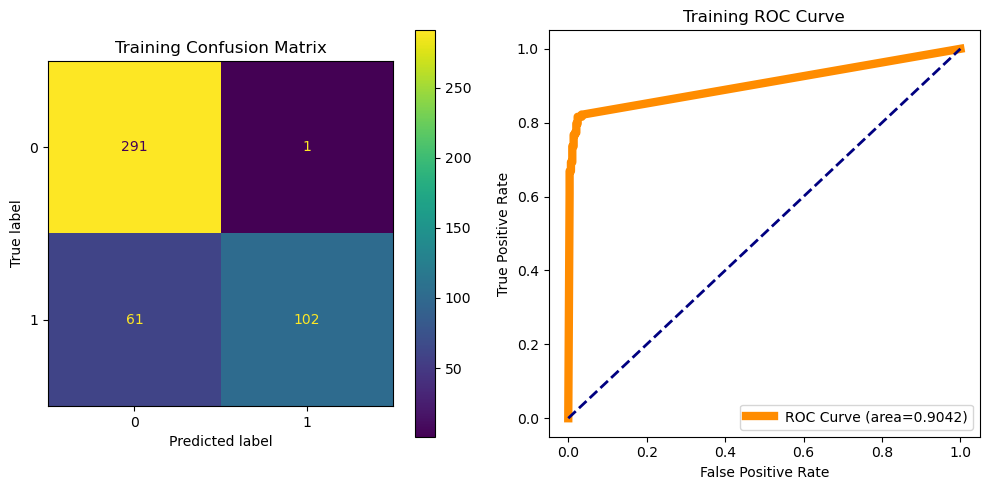

In [7]:
train_accuracies = []
train_auroc_scores = []
train_f1_scores = []
train_precision_scores = []
train_recall_scores = []
test_indices = []
kmeans_models = []
class_mappings = []

for M in range(0,30):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
    kmeans = KMeans(n_clusters=2, n_init=10) 
    kmeans.fit(X_train)
    distances = kmeans.transform(X_train) 

    test_index = X_test.index
    test_indices.append(test_index)
    kmeans_models.append(kmeans)
    
    distance_to_c1 = distances[:, 0]
    distance_to_c1_series = pd.Series(distance_to_c1, index=X_train.index)
    closest_30_c1 = distance_to_c1_series.sort_values(ascending=True).head(30).index
    values_c1, counts_c1 = np.unique(y_train[closest_30_c1], return_counts=True)
    majority_index_c1 = np.argmax(counts_c1)
    majority_class_c1 = values_c1[majority_index_c1] 
    
    distance_to_c2 = distances[:, 1]
    distance_to_c2_series = pd.Series(distance_to_c2, index=X_train.index)
    closest_30_c2 = distance_to_c2_series.sort_values(ascending=True).head(30).index
    values_c2, counts_c2 = np.unique(y_train[closest_30_c2], return_counts=True)
    majority_index_c2 = np.argmax(counts_c2)
    majority_class_c2 = values_c2[majority_index_c2] 
    
    class_mapping = {0: majority_class_c1, 1: majority_class_c2}
    class_mappings.append(class_mapping)
    cluster_labels_series = pd.Series(kmeans.labels_)
    y_train_pred = cluster_labels_series.map(class_mapping)
    
    probabilities = softmax(-distances, axis=1)
    positive_class_cluster = [cluster for cluster, label in class_mapping.items() if label == 'M'][0]
    y_train_pred_prob = probabilities[:, positive_class_cluster]
    
    train_auroc = roc_auc_score(y_train, y_train_pred_prob)
    train_accuracy = accuracy_score(y_train, y_train_pred)
    train_precision = precision_score(y_train, y_train_pred, pos_label='M')
    train_recall = recall_score(y_train, y_train_pred, pos_label='M')
    train_f1 = f1_score(y_train, y_train_pred, pos_label='M')

    train_auroc_scores.append(train_auroc)
    train_accuracies.append(train_accuracy)
    train_precision_scores.append(train_precision)
    train_recall_scores.append(train_recall)
    train_f1_scores.append(train_f1)

avg_train_accuracy = np.mean(train_accuracies)
avg_train_auroc = np.mean(train_auroc_scores)
avg_train_precision = np.mean(train_precision_scores)
avg_train_recall = np.mean(train_recall_scores)
avg_train_f1 = np.mean(train_f1_scores)

print('Average Train Accuracy of Monte Carlo Simulation with Unsupervised K-Means:', avg_train_accuracy)
print('Average Train AUROC of Monte Carlo Simulation with Unsupervised K-Means:', avg_train_auroc)
print('Average Train Precision of Monte Carlo Simulation with Unsupervised K-Means:', avg_train_precision)
print('Average Train Recall of Monte Carlo Simulation with Unsupervised K-Means:', avg_train_recall)
print('Average Train F1-Score of Monte Carlo Simulation with Unsupervised K-Means:', avg_train_f1)
print('')

train_conf_matrix = confusion_matrix(y_train, y_train_pred)
train_fpr, train_tpr, train_thresholds = roc_curve(y_train, y_train_pred_prob, pos_label='M')

fig, axis = plt.subplots(1, 2, figsize=(10, 5))
train_disp = ConfusionMatrixDisplay(confusion_matrix=train_conf_matrix)
train_disp.plot(ax=axis[0])
axis[0].set_title("Training Confusion Matrix")
axis[1].plot(train_fpr, train_tpr, color='darkorange', lw=6, label=f'ROC Curve (area={train_auroc:.4f})')
axis[1].plot([0,1], [0,1], color='navy', lw=2, linestyle='--')
axis[1].set_xlabel('False Positive Rate')
axis[1].set_ylabel('True Positive Rate')
axis[1].set_title('Training ROC Curve')
axis[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

To ensure that the algorithm is not trapped at a local minimum, I used the 'n_init' parameter which runs the algorithm multiple times with different random initializations for the centroids and chooses the clustering result with the lowest inertia. 

##### (C)

Average Test Accuracy of Monte Carlo Simulation with Unsupervised K-Means: 0.8450292397660818
Average Test AUROC of Monte Carlo Simulation with Unsupervised K-Means: 0.8974770310015128
Average Test Precision of Monte Carlo Simulation Unsupervised K-Means: 0.9929215364306643
Average Test Recall of Monte Carlo Simulation with Unsupervised K-Means: 0.5931845202402399
Average Test F1-Score of Monte Carlo Simulation with Unsupervised K-Means: 0.7409272927571732



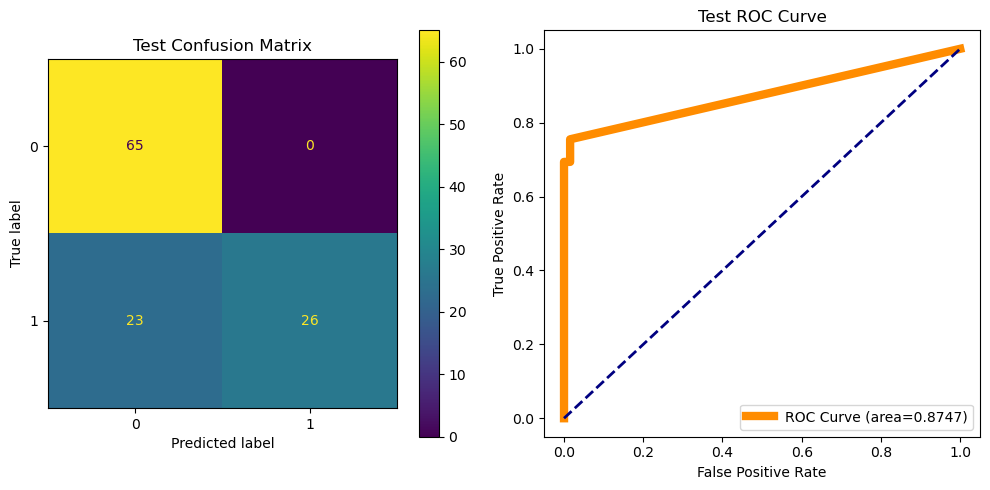

In [8]:
test_accuracies = []
test_auroc_scores = []
test_f1_scores = []
test_precision_scores = []
test_recall_scores = []

for M in range(0,30):
    kmeans = kmeans_models[M]
    class_map = class_mappings[M]
    test_set = wdbc_df.loc[test_indices[M]]
    X_test = test_set.iloc[:, 2:]
    y_test = test_set['Diagnosis']
    
    distances = kmeans.transform(X_test)
    closest_clusters = np.argmin(distances, axis=1)
    y_test_pred = pd.Series(closest_clusters).map(class_map)
    
    probabilities = softmax(-distances, axis=1)
    positive_class_cluster = [cluster for cluster, label in class_map.items() if label == 'M'][0]
    y_test_pred_prob = probabilities[:, positive_class_cluster]
    
    test_auroc = roc_auc_score(y_test, y_test_pred_prob)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    test_precision = precision_score(y_test, y_test_pred, pos_label='M')
    test_recall = recall_score(y_test, y_test_pred, pos_label='M')
    test_f1 = f1_score(y_test, y_test_pred, pos_label='M')

    test_auroc_scores.append(test_auroc)
    test_accuracies.append(test_accuracy)
    test_precision_scores.append(test_precision)
    test_recall_scores.append(test_recall)
    test_f1_scores.append(test_f1)

avg_test_accuracy_unsupervised = np.mean(test_accuracies)
avg_test_auroc_unsupervised = np.mean(test_auroc_scores)
avg_test_precision_unsupervised = np.mean(test_precision_scores)
avg_test_recall_unsupervised = np.mean(test_recall_scores)
avg_test_f1_unsupervised = np.mean(test_f1_scores)

print('Average Test Accuracy of Monte Carlo Simulation with Unsupervised K-Means:', avg_test_accuracy_unsupervised)
print('Average Test AUROC of Monte Carlo Simulation with Unsupervised K-Means:', avg_test_auroc_unsupervised)
print('Average Test Precision of Monte Carlo Simulation Unsupervised K-Means:', avg_test_precision_unsupervised)
print('Average Test Recall of Monte Carlo Simulation with Unsupervised K-Means:', avg_test_recall_unsupervised)
print('Average Test F1-Score of Monte Carlo Simulation with Unsupervised K-Means:', avg_test_f1_unsupervised)
print('')

test_conf_matrix = confusion_matrix(y_test, y_test_pred)
test_fpr, test_tpr, test_thresholds = roc_curve(y_test, y_test_pred_prob, pos_label='M')

fig, axis = plt.subplots(1, 2, figsize=(10, 5))
test_disp = ConfusionMatrixDisplay(confusion_matrix=test_conf_matrix)
test_disp.plot(ax=axis[0])
axis[0].set_title("Test Confusion Matrix")
axis[1].plot(test_fpr, test_tpr, color='darkorange', lw=6, label=f'ROC Curve (area={test_auroc:.4f})')
axis[1].plot([0,1], [0,1], color='navy', lw=2, linestyle='--')
axis[1].set_xlabel('False Positive Rate')
axis[1].set_ylabel('True Positive Rate')
axis[1].set_title('Test ROC Curve')
axis[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

#### (iv) Spectral Clustering

Average Accuracy of Monte Carlo Simulation with Spectral Clustering: 0.908611599297012
Average AUROC of Monte Carlo Simulation with Spectral Clustering: 0.8917274456952593
Average Precision of Monte Carlo Simulation with Spectral Clustering: 0.9210526315789476
Average Recall of Monte Carlo Simulation with Spectral Clustering: 0.8254716981132078
Average F1-Score of Monte Carlo Simulation with Spectral Clustering: 0.8706467661691545



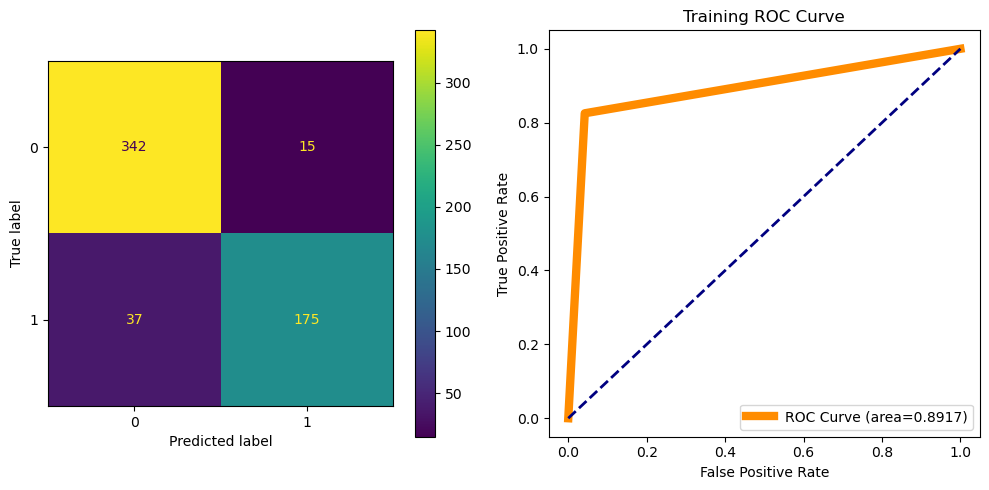

In [9]:
accuracies = []
auroc_scores = []
f1_scores = []
precision_scores = []
recall_scores = []

for M in range(0,30):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    spectral = SpectralClustering(n_clusters=2, affinity='rbf', gamma=0.001)
    cluster_labels = spectral.fit_predict(X_scaled)
    cluster_labels_series = pd.Series(cluster_labels, index=X.index)
    
    cluster_0_indices = [index for index, label in cluster_labels_series.items() if label == 0]
    cluster_1_indices = [index for index, label in cluster_labels_series.items() if label == 1]
    cluster_0_true = y[cluster_0_indices]
    cluster_1_true = y[cluster_1_indices]
    
    values_cluster_0, counts_cluster_0 = np.unique(cluster_0_true, return_counts=True)
    majority_index_cluster_0 = np.argmax(counts_cluster_0)
    majority_class_cluster_0 = values_cluster_0[majority_index_cluster_0] 
    values_cluster_1, counts_cluster_1 = np.unique(cluster_1_true, return_counts=True)
    majority_index_cluster_1 = np.argmax(counts_cluster_1)
    majority_class_cluster_1 = values_cluster_1[majority_index_cluster_1] 
    
    class_mapping = {0: majority_class_cluster_0, 1: majority_class_cluster_1}
    y_pred = cluster_labels_series.map(class_mapping)
    
    cluster_0_probabilities = [1 - (counts_cluster_0[1] / counts_cluster_0.sum()), counts_cluster_0[1] / counts_cluster_0.sum()] 
    cluster_1_probabilities = [1 - (counts_cluster_1[1] / counts_cluster_1.sum()), counts_cluster_1[1] / counts_cluster_1.sum()] 
    probability_map = {0: cluster_0_probabilities, 1: cluster_1_probabilities}
    y_probs = cluster_labels_series.map(probability_map)
    y_pred_prob = [probs[1] for probs in y_probs]
    
    auroc = roc_auc_score(y, y_pred_prob)
    accuracy = accuracy_score(y, y_pred)
    precision = precision_score(y, y_pred, pos_label='M')
    recall = recall_score(y, y_pred, pos_label='M')
    f1 = f1_score(y, y_pred, pos_label='M')
    
    auroc_scores.append(auroc)
    accuracies.append(accuracy)
    precision_scores.append(precision)
    recall_scores.append(recall)
    f1_scores.append(f1)

avg_accuracy_spectral = np.mean(accuracies)
avg_auroc_spectral = np.mean(auroc_scores)
avg_precision_spectral = np.mean(precision_scores)
avg_recall_spectral = np.mean(recall_scores)
avg_f1_spectral = np.mean(f1_scores)

print('Average Accuracy of Monte Carlo Simulation with Spectral Clustering:', avg_accuracy_spectral)
print('Average AUROC of Monte Carlo Simulation with Spectral Clustering:', avg_auroc_spectral)
print('Average Precision of Monte Carlo Simulation with Spectral Clustering:', avg_precision_spectral)
print('Average Recall of Monte Carlo Simulation with Spectral Clustering:', avg_recall_spectral)
print('Average F1-Score of Monte Carlo Simulation with Spectral Clustering:', avg_f1_spectral)
print('')

conf_matrix = confusion_matrix(y, y_pred)
fpr, tpr, thresholds = roc_curve(y, y_pred_prob, pos_label='M')

fig, axis = plt.subplots(1, 2, figsize=(10, 5))
cm_disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
cm_disp.plot(ax=axis[0])
axis[1].set_title("Confusion Matrix")
axis[1].plot(fpr, tpr, color='darkorange', lw=6, label=f'ROC Curve (area={auroc:.4f})')
axis[1].plot([0,1], [0,1], color='navy', lw=2, linestyle='--')
axis[1].set_xlabel('False Positive Rate')
axis[1].set_ylabel('True Positive Rate')
axis[1].set_title('Training ROC Curve')
axis[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

#### (iv) Compare

In [10]:
all_results = {'Method': ['Supervised L1-Penalized SVM', 'Semi-Supervised L1-Penalized SVM', 'Unsupervised K-Means Clustering', 'Spectral Clustering'],
               'Mean Accuracy': [avg_test_accuracy_supervised, avg_test_accuracy_semi_supervised, avg_test_accuracy_unsupervised, avg_accuracy_spectral], 
               'Mean AUROC Score': [avg_test_auroc_supervised, avg_test_auroc_semi_supervised, avg_test_auroc_unsupervised, avg_auroc_spectral], 
               'Mean Precision': [avg_test_precision_supervised, avg_test_precision_semi_supervised, avg_test_precision_unsupervised, avg_precision_spectral],
               'Mean Recall': [avg_test_recall_supervised, avg_test_recall_semi_supervised, avg_test_recall_unsupervised, avg_recall_spectral],
               'Mean F1-Score': [avg_test_f1_supervised, avg_test_f1_semi_supervised, avg_test_f1_unsupervised, avg_f1_spectral]}

all_results_df = pd.DataFrame(all_results)
all_results_df

,Method,Mean Accuracy,Mean AUROC Score,Mean Precision,Mean Recall,Mean F1-Score
0,Supervised L1-Penalized SVM,0.959649,0.990262,0.948750,0.946563,0.946787
1,Semi-Supervised L1-Penalized SVM,0.954386,0.967905,0.940257,0.935004,0.937149
2,Unsupervised K-Means Clustering,0.845029,0.897477,0.992922,0.593185,0.740927
3,Spectral Clustering,0.908612,0.891727,0.921053,0.825472,0.870647


We can see from the results above that indeed supervised learning on the whole dataset performs better than the semi-supervised and unsupervised methods investigated, which is to be expected. The most apparent conclusion we can draw from these results is that semi-supervised learning does not perform much worse than supervised learning, whereas the unsupervised methods definitely underperform compared to the supervised and semi-supervised methods. This shows if we do not have as much labeled data as we want, semi-supervised methods are quite viable and can yield relatively similar results to fully supervised learning. On the other hand, while unsupervised learning underperforms the other methods, it can still yield solid results in a situation where there is no labeled data. 

# Active Learning Using Support Vector Machines

### (a) Download the banknote authentication Data Set

In [11]:
bank_columns = ['variance', 'skewness', 'curtosis', 'entropy', 'class']
bank_df = pd.read_csv('../data/data_banknote_authentication.txt', names=bank_columns)
train_set = bank_df.sample(n=900, random_state=24)
test_set = bank_df.drop(train_set.index)
X_test = test_set.iloc[:, :-1]
y_test = test_set.iloc[:, -1]
print('Training Data Shape:', train_set.shape)
print('Test Data Shape:', test_set.shape)

Training Data Shape: (900, 5)
Test Data Shape: (472, 5)


### (b) Repeat each of the following two procedures 50 times

#### (i) Passive

In [12]:
passive_results = {num_train_samples: [] for num_train_samples in np.arange(10, 901, 10)}
for M in range(0,50):
    train_copy = train_set.copy()
    train_copy_class_0 = train_copy[train_copy['class'] == 0]
    train_copy_class_1 = train_copy[train_copy['class'] == 1]
    class_0_sample = train_copy_class_0.sample(n=5)
    class_1_sample = train_copy_class_1.sample(n=5)
    train_passive = pd.concat((class_0_sample, class_1_sample), axis=0)
    train_copy = train_copy.drop(train_passive.index)
    num_train = 10
    while not train_copy.empty:
        X_train = train_passive.iloc[:, :-1]
        y_train = train_passive.iloc[:, -1]
        param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100]}
        l1_svm = LinearSVC(penalty='l1', dual=False, max_iter=200000)
        grid_search = GridSearchCV(estimator=l1_svm, param_grid=param_grid, scoring='accuracy', cv=5)
        grid_search.fit(X_train, y_train)
        best_C = grid_search.best_params_['C']
        
        optimal_l1_svm = LinearSVC(penalty='l1', C=best_C, dual=False, max_iter=200000)
        optimal_l1_svm.fit(X_train, y_train)
        y_pred = optimal_l1_svm.predict(X_test)

        accuracy = accuracy_score(y_test, y_pred)
        test_error = 1 - accuracy
        
        passive_results[num_train].append(test_error)
        train_sample = train_copy.sample(n=10)
        train_passive = pd.concat((train_passive, train_sample), axis=0)
        train_copy = train_copy.drop(train_sample.index)
        num_train += 10

X_train = train_passive.iloc[:, :-1]
y_train = train_passive.iloc[:, -1]
param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100]}
l1_svm = LinearSVC(penalty='l1', dual=False, max_iter=200000)
grid_search = GridSearchCV(estimator=l1_svm, param_grid=param_grid, scoring='accuracy', cv=5)
grid_search.fit(X_train, y_train)
best_C = grid_search.best_params_['C']

optimal_l1_svm = LinearSVC(penalty='l1', C=best_C, dual=False, max_iter=200000)
optimal_l1_svm.fit(X_train, y_train)
y_pred = optimal_l1_svm.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
test_error = 1 - accuracy
passive_results[num_train].append(test_error)

mean_passive_results = {key: np.mean(value) for key, value in passive_results.items()}
passive_results_df = pd.DataFrame({'Number of Training Samples': list(mean_passive_results.keys()), 
                                   'Mean Test Error': list(mean_passive_results.values())})
passive_results_df

,Number of Training Samples,Mean Test Error
0,10,0.098136
1,20,0.057966
2,30,0.041017
3,40,0.035847
4,50,0.028983
...,...,...
85,860,0.015551
86,870,0.015593
87,880,0.015805
88,890,0.016398


#### (ii) Active

In [13]:
active_results = {num_train_samples: [] for num_train_samples in np.arange(10, 901, 10)}
for M in range(0,50):
    train_copy = train_set.copy()
    train_copy_class_0 = train_copy[train_copy['class'] == 0]
    train_copy_class_1 = train_copy[train_copy['class'] == 1]
    class_0_sample = train_copy_class_0.sample(n=5)
    class_1_sample = train_copy_class_1.sample(n=5)
    train_active = pd.concat((class_0_sample, class_1_sample), axis=0)
    train_copy = train_copy.drop(train_active.index)
    num_train = 10
    while not train_copy.empty:
        X_train = train_active.iloc[:, :-1]
        y_train = train_active.iloc[:, -1]
        param_grid = {'C': [0.01, 0.1, 1, 10]}
        l1_svm = LinearSVC(penalty='l1', dual=False, max_iter=300000)
        grid_search = GridSearchCV(estimator=l1_svm, param_grid=param_grid, scoring='accuracy', cv=5)
        grid_search.fit(X_train, y_train)
        best_C = grid_search.best_params_['C']
        
        optimal_l1_svm = LinearSVC(penalty='l1', C=best_C, dual=False, max_iter=300000)
        optimal_l1_svm.fit(X_train, y_train)
        y_pred = optimal_l1_svm.predict(X_test)

        accuracy = accuracy_score(y_test, y_pred)
        test_error = 1 - accuracy
        active_results[num_train].append(test_error)

        distances = optimal_l1_svm.decision_function(train_copy.iloc[:, :-1])
        closest_10_index = np.argsort(np.abs(distances))[:10]
        train_sample_active = train_copy.iloc[closest_10_index]
        train_active = pd.concat((train_active, train_sample_active), axis=0)
        train_copy = train_copy.drop(train_sample_active.index)
        num_train += 10

X_train = train_active.iloc[:, :-1]
y_train = train_active.iloc[:, -1]
param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100]}
l1_svm = LinearSVC(penalty='l1', dual=False, max_iter=300000)
grid_search = GridSearchCV(estimator=l1_svm, param_grid=param_grid, scoring='accuracy', cv=5)
grid_search.fit(X_train, y_train)
best_C = grid_search.best_params_['C']

optimal_l1_svm = LinearSVC(penalty='l1', C=best_C, dual=False, max_iter=300000)
optimal_l1_svm.fit(X_train, y_train)
y_pred = optimal_l1_svm.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
test_error = 1 - accuracy
active_results[num_train].append(test_error)

mean_active_results = {key: np.mean(value) for key, value in active_results.items()}
active_results_df = pd.DataFrame({'Number of Training Samples': list(mean_active_results.keys()), 'Mean Test Error': list(mean_active_results.values())})
active_results_df

,Number of Training Samples,Mean Test Error
0,10,0.116822
1,20,0.056398
2,30,0.045381
3,40,0.029068
4,50,0.019873
...,...,...
85,860,0.017034
86,870,0.017669
87,880,0.017034
88,890,0.017754


### (c) Average the 50 test errors

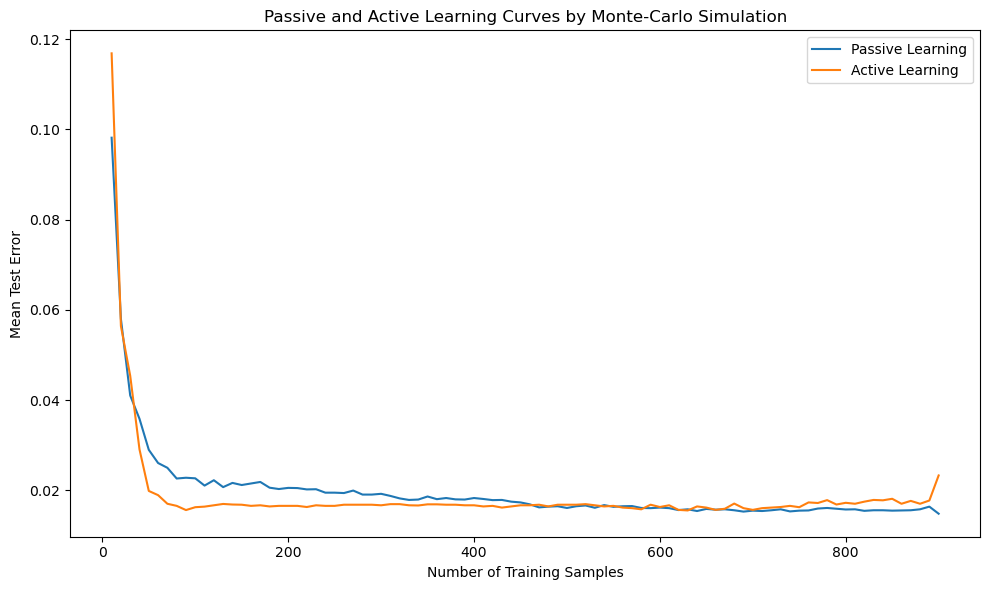

In [14]:
plt.figure(figsize=(10,6))
plt.plot(passive_results_df['Number of Training Samples'], passive_results_df['Mean Test Error'], label='Passive Learning')
plt.plot(active_results_df['Number of Training Samples'], active_results_df['Mean Test Error'], label='Active Learning')
plt.title('Passive and Active Learning Curves by Monte-Carlo Simulation')
plt.xlabel('Number of Training Samples')
plt.ylabel('Mean Test Error')
plt.legend()
plt.tight_layout()
plt.show()

We can see from the learning curves above that active learning seems to learn faster than passive learning as we increase the number of training samples. This is because, in active learning, we are deliberately selecting the most useful samples for model learning to add to the training dataset. Thus, we should expect that active learning should learn faster than passive learning, at least initially. However, what is interesting is that as we continue to increase the number of training samples, passive learning actually begins to outperform active learning. The learning curve for active learning seems to level out and even see worse performance as we start to reach the limit of the dataset. This could be due to selection bias or overfitting, showing that there might be diminshing returns from active learning. 